In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

In [2]:
DB_FILE = "sales_data.db"
CSV_EXPORT_FILE = "sales_summary.csv"

In [3]:
CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

In [4]:
plt.style.use("seaborn-v0_8-darkgrid")

In [5]:
conn = sqlite3.connect(DB_FILE)
cursor = conn.cursor()

# Create table if not exists
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL
)
""")

In [6]:
cursor.execute("SELECT COUNT(*) FROM sales")
if cursor.fetchone()[0] == 0:
    products = ["Laptop", "Mouse", "Keyboard", "Monitor", "Headphones", "Printer"]
    sample_data = [
        (random.choice(products), random.randint(1, 15), round(random.uniform(20, 1000), 2))
        for _ in range(20)
    ]
    cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
    conn.commit()

In [8]:
query = """
SELECT
    product,
    SUM(quantity) AS total_quantity,
    ROUND(SUM(quantity * price), 2) AS total_revenue
FROM sales
GROUP BY product
ORDER BY total_revenue DESC
"""
df = pd.read_sql_query(query, conn)
df

,product,total_quantity,total_revenue
0,Printer,36,20857.79
1,Monitor,32,18027.16
2,Mouse,30,9110.20
3,Headphones,26,6466.22
4,Laptop,10,5852.90
5,Keyboard,12,3179.91


In [9]:
total_qty = df["total_quantity"].sum()
total_revenue = df["total_revenue"].sum()
top_product = df.iloc[0]["product"]

print(f"Total Quantity Sold: {total_qty}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Top Product by Revenue: {top_product}")

Total Quantity Sold: 146
Total Revenue: $63,494.18
Top Product by Revenue: Printer


In [10]:
df.to_csv(CSV_EXPORT_FILE, index=False)
print(f"✅ Sales summary exported to {CSV_EXPORT_FILE}")


✅ Sales summary exported to sales_summary.csv


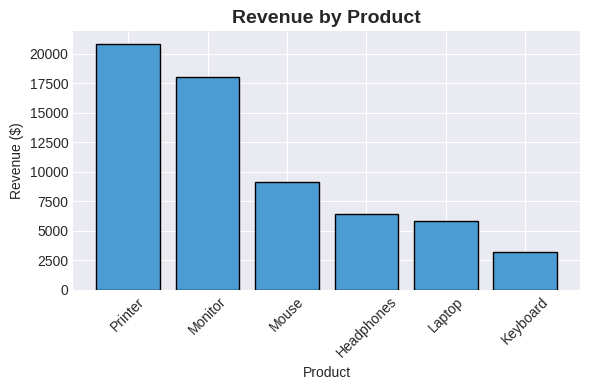

In [11]:
plt.figure(figsize=(6,4))
plt.bar(df["product"], df["total_revenue"], color="#4B9CD3", edgecolor="black")
plt.title("Revenue by Product", fontsize=14, weight="bold")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "revenue_chart.png"))
plt.show()

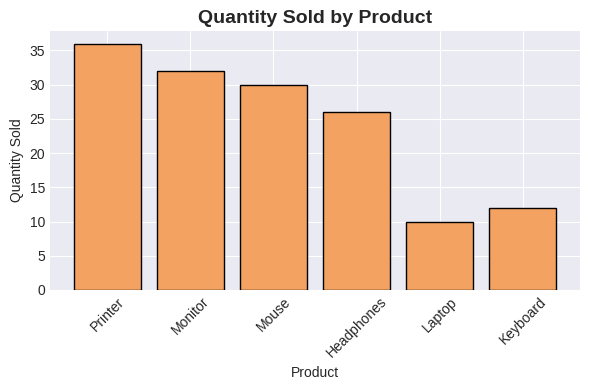

In [12]:
plt.figure(figsize=(6,4))
plt.bar(df["product"], df["total_quantity"], color="#F4A261", edgecolor="black")
plt.title("Quantity Sold by Product", fontsize=14, weight="bold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "quantity_chart.png"))
plt.show()

In [13]:
conn.close()